In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.inspection import permutation_importance

Dataset: <br>
League - All <br>
Year(s) - 2021-25 <br>

In [2]:
# Data Collection
# --- 1. DATA COLLECTION ---
# Import data from csv file
df = pd.read_csv('../data/v0/Final_DataSet_All.csv')
# df


In [3]:
# --- 2. PRE-PROCESSING ---
# Filter for FT to determine outcomes
filtered = df.loc[df['Time'] == 'FT'].copy()
conditions = [
    (filtered['Home_Score'] > filtered['Away_Score']),
    (filtered['Away_Score'] > filtered['Home_Score']),
    (filtered['Home_Score'] == filtered['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')

match_outcome_dict = dict(zip(filtered['Game_ID'], filtered['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(match_outcome_dict)

# Drop 'FT' and 'Cup' games, handle time expressions
# Use .copy() to avoid SettingWithCopyWarning
df_filtered = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_filtered['Time'] = df_filtered['Time'].apply(eval)

EDA

In [4]:
# df_filtered.describe()
df_filtered.describe(include=['object'])

,Game_ID,Matchweek,Game_Type,Team,Match_URL,Event_Type,Player_1,Pos_1,Player_2,Pos_2,Note,Match_Outcomes
count,106598,106598,106598,106598,106598,106598,106598,106598,78813,78813,106598,106598
unique,6310,38,1,2,7155,4,3997,14,4634,15,6,3
top,120230701,4,League,Home,https://fbref.com/en/matches/bc7df752/Bayern-M...,Substitution,Vincenzo Grifo,FW,Kevin Behrens,FW,Neutral Sub,Home_Win
freq,99,3054,106598,54573,42,78813,266,25033,131,16109,60365,48171


Train/Test Split

In [5]:
# --- 3. TRAIN/TEST SPLIT ---
# Isolate features and target
X = df_filtered[['Time', 'Home_Score', 'Away_Score', 'Home_Red_Count', 'Away_Red_Count', 
                 'Home_Off_Sub_Count', 'Home_Def_Sub_Count', 'Away_Off_Sub_Count', 'Away_Def_Sub_Count']]
y = df_filtered['Match_Outcomes']

# Split: 80% Train, 20% Test. 'stratify' ensures balanced classes in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

Randomized Search - Find best k value

In [6]:
# --- 4. PIPELINE OPTIMIZATION ---
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

param_distributions = {
    'pca__n_components': range(1, X.shape[1] + 1),
    'knn__n_neighbors': range(1, 51),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

random_search = RandomizedSearchCV(
    pipeline, param_distributions=param_distributions, n_iter=30, 
    cv=5, scoring='accuracy', random_state=42, refit=True
)
random_search.fit(X_train, y_train)

print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Training CV Accuracy: {random_search.best_score_:.4f}")

Best Parameters: {'pca__n_components': 8, 'knn__weights': 'distance', 'knn__n_neighbors': 30, 'knn__metric': 'euclidean'}
Best Training CV Accuracy: 0.6829



Classification Report:
              precision    recall  f1-score   support

    Away_Win       0.67      0.73      0.70      6779
        Draw       0.56      0.45      0.50      4907
    Home_Win       0.75      0.77      0.76      9634

    accuracy                           0.68     21320
   macro avg       0.66      0.65      0.65     21320
weighted avg       0.68      0.68      0.68     21320



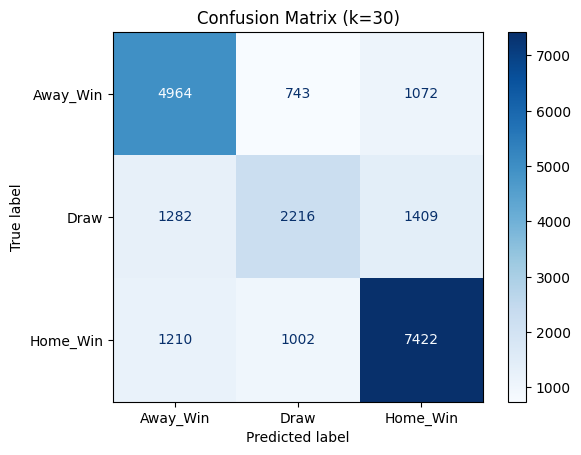

In [7]:
# --- 5. EVALUATION & CONFUSION MATRIX ---
y_pred = random_search.predict(X_test)
target_names = sorted(y.unique())

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (k={random_search.best_params_['knn__n_neighbors']})")
plt.grid(False)
plt.show()

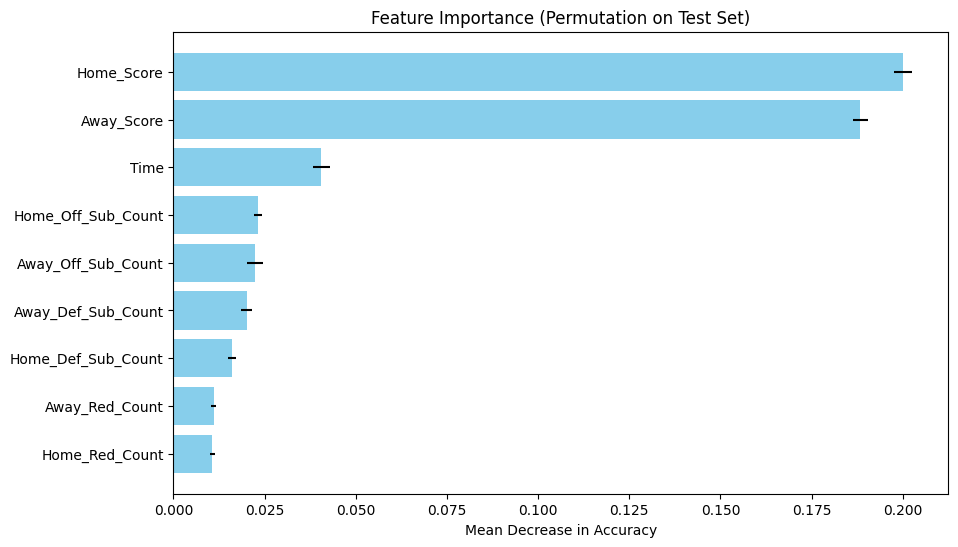

In [8]:
# --- 6. FEATURE ANALYSIS: PERMUTATION IMPORTANCE ---
# Determines feature impact by shuffling values and measuring accuracy drop
result = permutation_importance(random_search, X_test, y_test, n_repeats=10, random_state=42)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance_mean'], 
         xerr=feature_importance['importance_std'], color='skyblue')
plt.title("Feature Importance (Permutation on Test Set)")
plt.xlabel("Mean Decrease in Accuracy")
plt.gca().invert_yaxis()
plt.show()

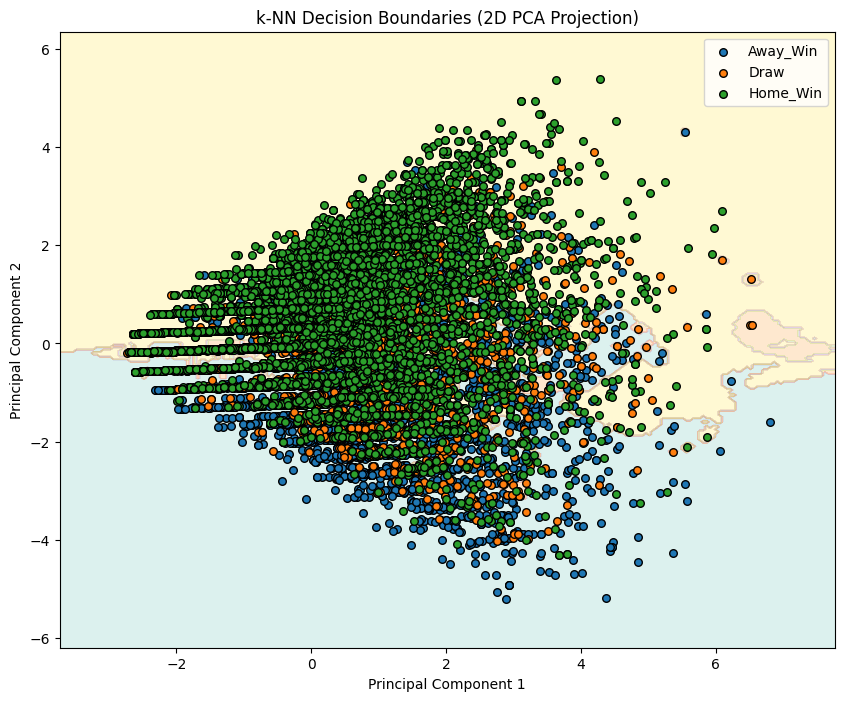

In [9]:
# --- 7. MODEL VISUALIZATION: 2D PCA DECISION BOUNDARIES ---
# Visualizes how k-NN separates classes in a reduced 2D space
best_pca = random_search.best_estimator_.named_steps['pca']
scaler = random_search.best_estimator_.named_steps['scaler']

# Transform test data to 2D for visualization
X_scaled_test = scaler.transform(X_test)
X_pca_2d = best_pca.transform(X_scaled_test)[:, :2]

# Create a mesh grid to plot boundaries
h = .05
x_min, x_max = X_pca_2d[:, 0].min() - 1, X_pca_2d[:, 0].max() + 1
y_min, y_max = X_pca_2d[:, 1].min() - 1, X_pca_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Re-fit a 2D-only k-NN for the visual map
viz_knn = KNeighborsClassifier(n_neighbors=random_search.best_params_['knn__n_neighbors'], 
                               weights=random_search.best_params_['knn__weights'])
viz_knn.fit(X_pca_2d, y_test)
Z = viz_knn.predict(np.c_[xx.ravel(), yy.ravel()])

# Convert predictions to numeric for contour plotting
label_to_int = {lab: i for i, lab in enumerate(viz_knn.classes_)}
Z_int = np.array([label_to_int[val] for val in Z]).reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_int, alpha=0.3, cmap='Set3')
for lab in viz_knn.classes_:
    mask = (y_test == lab)
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], label=lab, edgecolor='k', s=30)

plt.title("k-NN Decision Boundaries (2D PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()